# 2.6. Probability and Statistics
D2L의 Probability and Statistics 장을 PyTorch 기준으로 정리함.

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [1]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt
from torch.distributions.multinomial import Multinomial
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.manual_seed(0)
random.seed(0)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. 왜 머신러닝에서 확률이 필요한가?

지도학습에서는 이미 알고 있는 입력 feature를 이용해서 모르는 target을 예측한다.

예를 들어서 다음과 같은 문제를 생각할 수 있다.
- 환자의 정보가 주어졌을 때 1년 안에 심장마비가 올 확률은?
- 이미지가 주어졌을 때 고양이일 확률은?
- 문장이 주어졌을 때 긍정 리뷰일 확률은?
- 어떤 데이터가 정상 데이터인지 이상치인지?

이런 문제들은 대부분 정답을 100% 확실하게 말할 수 없다.

머신러닝에서는 단순히 정답은 A다라고 말하는 것보다 정답이 A일 가능성이 높다처럼 확률적으로 생각하는 경우가 많다.
확률은 불확실한 상황에서 사건이 얼마나 일어날 것 같은지를 수학적으로 표현하는 방법이다.

## 2. 확률과 통계의 차이

동전을 던진다고 해보자.

공정한 동전이라면 앞면이 나올 확률은 다음과 같다.

$$
P(\text{heads}) = 0.5
$$

여기서 0.5는 동전 자체가 가진 이론적인 성질이다.  
이것이 확률이다.

그런데 실제로 동전을 100번 던졌을 때 앞면이 정확히 50번 나올 필요는 없다.

예를 들어서 앞면 45번, 뒷면 55번이 나올 수도 있다.

이때

$$
\frac{\text{앞면이 나온 횟수}}{\text{전체 던진 횟수}}
$$

는 관측된 데이터에서 계산한 값이다.  
이것은 통계량이다.

정리하면 다음과 같다.

- 확률: 데이터가 만들어지는 과정의 이론적 성질
- 통계량: 실제로 관측한 데이터에서 계산한 값
- 추정량: 통계량을 이용해 알 수 없는 확률이나 파라미터를 추정하는 방법

우리는 실제 확률을 모를 때 데이터를 모아서 통계적으로 추정한다.

## 3. 동전 던지기 직접 구현

먼저 Python의 random.random()을 사용해서 동전 던지기를 흉내내보자

random.random()은 0 이상 1 미만의 난수를 만든다.

- 값이 0.5보다 크면 앞면
- 값이 0.5 이하이면 뒷면

이라고 정했다.

In [2]:
num_tosses = 100

heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads

print("heads, tails:", [heads, tails])
print("estimated P(heads):", heads / num_tosses)
print("estimated P(tails):", tails / num_tosses)

heads, tails: [63, 37]
estimated P(heads): 0.63
estimated P(tails): 0.37


실행할 때마다 결과는 조금씩 달라진다.

공정한 동전의 실제 확률은 0.5지만, 100번 던졌을 때 관측된 비율은 0.5가 아닐 수 있다.

## 4. Multinomial로 동전 던지기

동전 던지기는 가능한 결과가 2개다.

- index 0: 앞면
- index 1: 뒷면

각 결과의 확률을 다음처럼 둘 수 있다.

$$
[0.5, 0.5]
$$

PyTorch에서는 `torch.distributions.multinomial.Multinomial`을 사용해서 여러 번의 시행 결과를 한 번에 샘플링할 수 있다.

In [3]:
fair_probs = torch.tensor([0.5, 0.5])

# 100번 던졌을 때 앞면과 뒷면이 각각 몇 번 나왔는지
counts = Multinomial(total_count=100, probs=fair_probs).sample()

print(counts)
print("estimated probabilities:", counts / 100)

tensor([53., 47.])
estimated probabilities: tensor([0.5300, 0.4700])


## 5. 샘플 수가 더 많아지면 ?

이번에는 100번이 아니라 10,000번 던져보자.

In [4]:
counts = Multinomial(total_count=10000, probs=fair_probs).sample()

print(counts)
print("estimated probabilities:", counts / 10000)

tensor([4964., 5036.])
estimated probabilities: tensor([0.4964, 0.5036])


샘플 수가 커질수록 관측된 비율은 실제 확률인 0.5에 가까워진다.

이 현상을 대수의 법칙이라고 한다.

대략적으로 말하면 다음과 같다.

반복 횟수가 많아질수록 표본 평균은 실제 평균에 가까워진다.

동전 던지기에서는 다음처럼 이해하면 된다.

- 적게 던지면 앞면 비율이 0.4나 0.6처럼 흔들릴 수 있다.
- 많이 던지면 앞면 비율이 0.5 근처로 안정된다.

하지만 많이 던진다고 해서 매번 앞면과 뒷면 개수가 정확히 같아지는 것은 아니다.  
비율이 실제 확률에 가까워진다는 뜻이다.

## 6. 관측 비율이 수렴하는 과정 시각화

동전을 10,000번 던지면서, 매 시점마다 앞면과 뒷면의 누적 비율을 계산해보자.

tensor([[1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.]])
torch.Size([10000, 2])
tensor([[1.0000, 0.0000],
        [0.5000, 0.5000],
        [0.6667, 0.3333],
        [0.7500, 0.2500],
        [0.6000, 0.4000],
        [0.6667, 0.3333],
        [0.7143, 0.2857],
        [0.6250, 0.3750],
        [0.5556, 0.4444],
        [0.5000, 0.5000]])


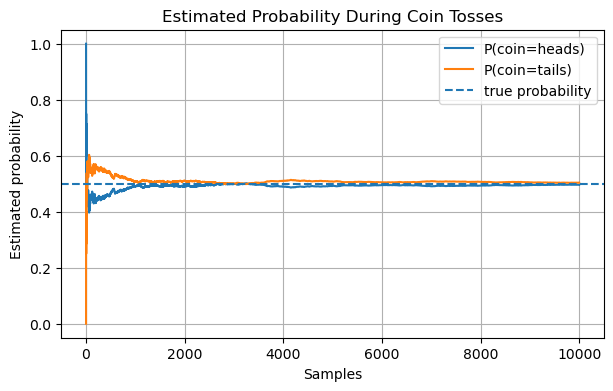

In [28]:
num_samples = 10000

# 한 번에 하나의 동전 던지기를 10,000번 수행
counts = Multinomial(total_count=1, probs=fair_probs).sample((num_samples,))

print(counts[:10])
print(counts.shape)

cum_counts = counts.cumsum(dim=0)

# 각 시점까지의 전체 시행 횟수
total_counts = cum_counts.sum(dim=1, keepdim=True)

# 각 시점까지의 앞면/뒷면 누적 비율
estimates = cum_counts / total_counts

print(estimates[:10])

plt.figure(figsize=(7, 4))
plt.plot(estimates[:, 0].numpy(), label="P(coin=heads)")
plt.plot(estimates[:, 1].numpy(), label="P(coin=tails)")
plt.axhline(y=0.5, linestyle="--", label="true probability")
plt.xlabel("Samples")
plt.ylabel("Estimated probability")
plt.title("Estimated Probability During Coin Tosses")
plt.legend()
plt.grid(True)
plt.show()

초반에는 추정값이 크게 흔들린다.

예를 들어서 처음 1번 던졌는데 앞면이 나오면 앞면 비율은 1.0이다.  
처음 2번 던졌는데 앞면, 뒷면이 나오면 앞면 비율은 0.5다.

샘플이 적을 때는 하나의 결과가 추정값에 큰 영향을 준다.

하지만 샘플이 많아질수록 한 번의 결과가 전체 비율에 미치는 영향이 작아진다.  
그래서 추정값이 점점 0.5 근처로 안정된다.

## 7. 표본공간과 사건

확률을 더 정확히 다루려면 용어를 정리해야 한다.

### 표본공간

표본공간은 가능한 모든 결과의 집합이다.

동전 한 번 던지기의 표본공간은 다음과 같다.

$$
\mathcal{S} = \{\text{heads}, \text{tails}\}
$$

주사위 한 번 던지기의 표본공간은 다음과 같다.

$$
\mathcal{S} = \{1, 2, 3, 4, 5, 6\}
$$

동전 두 번 던지기의 표본공간은 다음과 같다.

$$
\mathcal{S} =
\{
(H,H), (H,T), (T,H), (T,T)
\}
$$

### 사건

사건은 표본공간의 부분집합이다.

예를 들어서 동전을 두 번 던질 때  
첫 번째 동전이 앞면이다라는 사건은 다음과 같다.

$$
A = \{(H,H), (H,T)\}
$$

주사위를 한 번 던질 때 홀수가 나온다라는 사건은 다음과 같다.

$$
B = \{1, 3, 5\}
$$

사건은 가능한 결과들 중에서 우리가 관심 있는 결과들의 묶음이다.

## 8. 확률의 기본 규칙

### 1. 확률은 0 이상이다.

$$
P(A) \geq 0
$$

확률이 음수일 수는 없다.

### 2. 전체 표본공간의 확률은 1이다.

$$
P(\mathcal{S}) = 1
$$

가능한 모든 결과 중 하나는 반드시 일어난다.

### 3. 서로 겹치지 않는 사건들의 합집합 확률은 각 확률의 합이다.

서로 겹치지 않는 사건을 mutually exclusive, 상호배타적이라고 한다.

$$
A_i \cap A_j = \emptyset \quad (i \neq j)
$$

이면,

$$
P\left(\bigcup_i A_i\right) = \sum_i P(A_i)
$$

예를 들어서 주사위에서 1이 나오는 사건과 2가 나오는 사건은 동시에 일어날 수 없다.

따라서

$$
P(1 \text{ or } 2) = P(1) + P(2)
$$

이다.

## 9. 확률변수

확률변수는 랜덤한 실험 결과를 숫자나 값으로 바꿔주는 함수다.

예를 들어 동전을 던졌을 때 다음처럼 정의할 수 있다.

$$
X =
\begin{cases}
1, & \text{heads} \\
0, & \text{tails}
\end{cases}
$$

그러면 X는 확률변수다.

주사위를 던져서 나온 눈을 그대로 X라고 해도 확률변수다.

$$
X \in \{1,2,3,4,5,6\}
$$

중요한 점은 확률변수의 값 하나하나가 사건에 대응된다는 것이다.

예를 들어

$$
P(X = 3)
$$

은 확률변수 X가 3이라는 값을 가질 확률이다.

또는

$$
P(1 \leq X \leq 3)
$$

처럼 범위에 대한 확률도 말할 수 있다.

## 10. 이산 확률변수와 연속 확률변수

확률변수는 크게 두 종류로 나눌 수 있다.

### 이산 확률변수

값을 셀 수 있는 경우다.

예:

- 동전: 앞면 / 뒷면
- 주사위: 1, 2, 3, 4, 5, 6
- 클래스 라벨: 고양이 / 강아지 / 자동차

이산 확률변수에서는 특정 값의 확률을 직접 말할 수 있다.

$$
P(X = 3)
$$

### 연속 확률변수

값이 연속적인 경우다.

예:

- 키
- 몸무게
- 온도
- 시간
- 좌표값

연속 확률변수에서는 정확히 특정 값이 나올 확률은 보통 0이다.

예를 들어서 어떤 사람의 키가 정확히 180.000000000cm일 확률은 사실상 의미가 없다.

대신 구간 확률을 본다.

$$
P(179 \leq X \leq 181)
$$

연속 확률변수에서는 확률밀도함수를 적분해서 구간 확률을 계산한다.

## 11. 여러 개의 확률변수

머신러닝에서는 확률변수 하나만 보는 경우보다 여러 개를 같이 보는 경우가 훨씬 많다.

예를 들어 환자 데이터를 생각해보자.

- X1: 열이 있는가?
- X2: 기침이 있는가?
- X3: 후각을 잃었는가?
- Y: 코로나에 걸렸는가?

이때 우리는 보통 다음을 알고 싶다.

$$
P(Y \mid X_1, X_2, X_3)
$$

증상들이 주어졌을 때 병에 걸렸을 확률을 알고 싶은 것이다.

여러 확률변수를 함께 다룰 때는 결합확률, 조건부확률, 주변확률이 중요해진다.

## 12. 결합확률

결합확률은 여러 사건이 동시에 일어날 확률이다.

두 확률변수 A, B가 있을 때

$$
P(A=a, B=b)
$$

는 A가 a이고 B가 b일 확률이다.

쉼표는 여기서 and의 의미다.

예를 들어서

$$
P(\text{fever}=1, \text{covid}=1)
$$

은 열이 있고 동시에 코로나에 걸렸을 확률이다.

결합확률은 각각의 단일 확률보다 클 수 없다.

$$
P(A=a, B=b) \leq P(A=a)
$$

$$
P(A=a, B=b) \leq P(B=b)
$$

왜냐하면 A와 B가 동시에 일어나려면 A도 일어나야 하고 B도 일어나야 하기 때문이다.

## 13. 주변확률

결합확률에서 특정 변수를 제거하고 하나의 변수에 대한 확률만 얻는 것을 주변화라고 한다.

예를 들어 A의 확률을 알고 싶다면 B가 가질 수 있는 모든 값에 대해 더하면 된다.

$$
P(A=a) = \sum_v P(A=a, B=v)
$$

예를 들어 B가 0 또는 1만 가질 수 있다면

$$
P(A=a) = P(A=a, B=0) + P(A=a, B=1)
$$

이다.

이것은 전체 경우를 쪼개서 다시 더하는 방식이다.

## 14. 조건부확률

조건부확률은 어떤 사건이 이미 일어났다고 알고 있을 때, 다른 사건이 일어날 확률이다.

$$
P(B=b \mid A=a)
$$

는 A가 a라는 사실을 알고 있을 때 B가 b일 확률이다.

정의는 다음과 같다.

$$
P(B=b \mid A=a) = \frac{P(A=a, B=b)}{P(A=a)}
$$

말로 풀면 다음과 같다.

A가 일어난 세계만 남겨놓고,  
그 안에서 B도 같이 일어난 비율을 보는 것이다.

예를 들어서

$$
P(\text{covid}=1 \mid \text{fever}=1)
$$

은 열이 있다는 조건에서 코로나일 확률이다.

In [29]:
# 간단한 조건부확률 예시
# 전체 1000명 중:
# 열이 있는 사람 100명
# 열이 있고 코로나인 사람 30명

p_fever = 100 / 1000
p_fever_and_covid = 30 / 1000

p_covid_given_fever = p_fever_and_covid / p_fever

print("P(covid | fever):", p_covid_given_fever)

P(covid | fever): 0.3


## 15. 베이즈 정리

베이즈 정리는 조건부확률의 방향을 바꾸는 공식이다.

$$
P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}
$$

이 공식이 중요한 이유는 다음과 같다.

우리는 가끔 직접 알고 싶은 확률을 바로 구하기 어렵다.

예를 들어

$$
P(\text{disease} \mid \text{positive test})
$$

를 알고 싶다고 하자.

검사 결과가 양성일 때 실제로 병에 걸렸을 확률이다.

그런데 병에 걸렸을 때 양성이 나올 확률은 비교적 알기 쉽다.

$$
P(\text{positive test} \mid \text{disease})
$$

이것은 검사기의 민감도 같은 값이기 때문이다.

베이즈 정리는 이런 식으로 조건의 방향을 바꿔준다.

### 베이즈 정리 해석

$$
P(A \mid B)
$$

는 posterior, 사후확률이다.  
증거 B를 본 뒤 A가 맞을 확률이다.

$$
P(A)
$$

는 prior, 사전확률이다.  
증거를 보기 전 A가 맞을 확률이다.

$$
P(B \mid A)
$$

는 likelihood, 가능도다.  
A가 참일 때 증거 B가 관측될 가능성이다.

$$
P(B)
$$

는 evidence, 증거의 전체 확률이다.

## 16. HIV 검사 예시

D2L에서는 HIV 검사 예시로 베이즈 정리를 설명한다.

첫 번째 검사 D1의 조건부확률은 다음과 같다고 하자.

| 조건 | 값 |
|---|---:|
| 감염자가 양성으로 나올 확률 P(D1=1 \| H=1) | 1.00 |
| 건강한 사람이 양성으로 나올 확률 P(D1=1 \| H=0) | 0.01 |
| 감염자가 음성으로 나올 확률 P(D1=0 \| H=1) | 0.00 |
| 건강한 사람이 음성으로 나올 확률 P(D1=0 \| H=0) | 0.99 |

그리고 전체 인구에서 HIV에 걸린 비율이 0.15% 같다고 하자.

$$
P(H=1) = 0.0015
$$

$$
P(H=1 \mid D_1=1)
$$

검사 결과가 양성일 때 실제로 HIV일 확률이다.

In [30]:
# Prior
p_hiv = 0.0015
p_healthy = 1 - p_hiv

# Test 1
p_d1_pos_given_hiv = 1.0
p_d1_pos_given_healthy = 0.01

# Marginal probability of positive test
p_d1_pos = (
    p_d1_pos_given_hiv * p_hiv
    + p_d1_pos_given_healthy * p_healthy
)

# Bayes theorem
p_hiv_given_d1_pos = (p_d1_pos_given_hiv * p_hiv) / p_d1_pos

print("P(D1=1):", p_d1_pos)
print("P(H=1 | D1=1):", p_hiv_given_d1_pos)

P(D1=1): 0.011485
P(H=1 | D1=1): 0.13060513713539398


결과는 약 0.1306이다.

검사기가 꽤 정확해 보여도 양성 결과를 받았을 때 실제 감염 확률은 약 13.06%다.

이게 직관에 어긋나 보이는 이유는 base rate, 사전확률 때문이다.

병 자체가 매우 드물면, 건강한 사람 중 일부가 잘못 양성으로 나오는 false positive가 실제 감염자 수보다 많아질 수 있다.

따라서 검사 정확도 99% 같은 말만 보면 안 된다.  
반드시 병의 기본 발생률도 같이 봐야 한다.

## 17. 두 번째 검사를 추가하면 어떻게 되는가?

두 번째 검사 D2는 다음과 같다고 하자.

| 조건 | 값 |
|---|---:|
| 감염자가 양성으로 나올 확률 P(D2=1 \| H=1) | 0.98 |
| 건강한 사람이 양성으로 나올 확률 P(D2=1 \| H=0) | 0.03 |
| 감염자가 음성으로 나올 확률 P(D2=0 \| H=1) | 0.02 |
| 건강한 사람이 음성으로 나올 확률 P(D2=0 \| H=0) | 0.97 |

두 검사 결과가 모두 양성이라고 하자.

그리고 두 검사가 HIV 여부를 조건으로 서로 독립이라고 가정한다.

그러면 다음처럼 계산할 수 있다.

$$
P(D_1=1, D_2=1 \mid H=1)
=
P(D_1=1 \mid H=1)P(D_2=1 \mid H=1)
$$

$$
P(D_1=1, D_2=1 \mid H=0)
=
P(D_1=1 \mid H=0)P(D_2=1 \mid H=0)
$$

In [ ]:
# Test 2
p_d2_pos_given_hiv = 0.98
p_d2_pos_given_healthy = 0.03

# Conditional independence assumption
p_both_pos_given_hiv = p_d1_pos_given_hiv * p_d2_pos_given_hiv
p_both_pos_given_healthy = p_d1_pos_given_healthy * p_d2_pos_given_healthy

# Marginal probability of both tests being positive
p_both_pos = (
    p_both_pos_given_hiv * p_hiv
    + p_both_pos_given_healthy * p_healthy
)

# Bayes theorem
p_hiv_given_both_pos = (p_both_pos_given_hiv * p_hiv) / p_both_pos

print("P(D1=1, D2=1 | H=1):", p_both_pos_given_hiv)
print("P(D1=1, D2=1 | H=0):", p_both_pos_given_healthy)
print("P(D1=1, D2=1):", p_both_pos)
print("P(H=1 | D1=1, D2=1):", p_hiv_given_both_pos)

결과는 약 0.8307이다.

첫 번째 검사만 양성일 때는 실제 감염 확률이 약 13.06%였지만,  
서로 독립적인 두 검사가 모두 양성이라면 실제 감염 확률은 약 83.07%까지 올라간다.

여기서 중요한 것은 두 검사가 조건부 독립이라는 가정이다.

같은 검사를 두 번 반복하면 정보가 거의 늘어나지 않는다.  
하지만 서로 다른 방식의 독립적인 검사를 추가하면 판단에 필요한 정보가 늘어난다.

머신러닝으로 비유하면 feature가 하나 더 추가된 것과 비슷하다.

## 18. 독립성

두 확률변수 A, B가 독립이라는 것은 A를 알아도 B에 대한 믿음이 바뀌지 않는다는 뜻이다.

수식으로는 다음과 같다.

$$
P(A \mid B) = P(A)
$$

또는

$$
P(A, B) = P(A)P(B)
$$

예를 들어 서로 다른 두 동전을 던진다고 하자.

첫 번째 동전이 앞면인지 알게 되어도  
두 번째 동전이 앞면일 확률은 여전히 0.5다.

두 사건은 독립이다.

반대로 병과 증상은 보통 독립이 아니다.

열이 있다는 사실을 알면  
특정 병에 걸렸을 확률에 대한 믿음이 바뀐다.

In [31]:
# 예시: 두 동전
p_a_heads = 0.5
p_b_heads = 0.5

p_a_and_b_heads_if_independent = p_a_heads * p_b_heads

print("P(A=heads and B=heads):", p_a_and_b_heads_if_independent)

P(A=heads and B=heads): 0.25


## 19. 조건부 독립

조건부 독립은 어떤 조건 C가 주어졌을 때 A와 B가 독립이라는 뜻이다.

$$
P(A, B \mid C) = P(A \mid C)P(B \mid C)
$$

HIV 검사 예시에서는 다음과 같은 가정을 했다.

HIV 감염 여부 H가 주어지면,  
검사 D1과 D2의 결과는 서로 독립이다.

$$
P(D_1, D_2 \mid H) = P(D_1 \mid H)P(D_2 \mid H)
$$

이 가정이 있었기 때문에 두 검사 결과를 곱해서 계산할 수 있었다.

하지만 현실에서는 이 가정이 항상 맞지 않는다.

예를 들어 두 검사가 같은 원리로 동작한다면,  
둘 다 같은 이유로 틀릴 수 있다.

따라서 독립성 가정은 편리하지만, 무조건 믿으면 안 된다.

## 20. 기댓값

기댓값은 확률적으로 평균적으로 기대되는 값이다.

이산 확률변수 X의 기댓값은 다음과 같다.

$$
E[X] = \sum_x xP(X=x)
$$

가능한 값에 그 값이 나올 확률을 곱한 뒤 모두 더한다.

예를 들어서 어떤 투자의 수익률이 다음과 같다고 하자.

| 결과 | 수익 배수 | 확률 |
|---|---:|---:|
| 실패 | 0배 | 0.5 |
| 보통 성공 | 2배 | 0.4 |
| 대성공 | 10배 | 0.1 |

기댓값은 다음과 같다.

$$
0.5 \cdot 0 + 0.4 \cdot 2 + 0.1 \cdot 10 = 1.8
$$

이건 평균적으로 1.8배 수익을 기대할 수 있다는 뜻이다.

In [35]:
returns = torch.tensor([0.0, 2.0, 10.0])
probs = torch.tensor([0.5, 0.4, 0.1])

expected_return = (returns * probs).sum()

print("Expected return:", expected_return.item())

Expected return: 1.7999999523162842


기댓값은 단순히 가장 가능성 높은 값이 아니다.

위 예시에서 가장 가능성 높은 결과는 0배 손실이다.  
확률이 0.5로 가장 크기 때문이다.

하지만 기댓값은 1.8배다.

기댓값은 가능한 모든 결과를 확률로 가중평균한 값이다.

## 21. 함수의 기댓값

확률변수 X 자체가 아니라, X에 어떤 함수를 적용한 값의 평균도 구할 수 있다.

$$
E[f(X)] = \sum_x f(x)P(x)
$$

수익률 자체보다 만족도를 따로 정의할 수 있다.

수익률이 커져도 만족도가 선형으로 증가하지 않을 수 있다.

예를 들어 다음처럼 utility를 정의해보자.

| 수익 배수 | utility |
|---:|---:|
| 0 | -1 |
| 2 | 2 |
| 10 | 4 |

그러면 기대 utility는 다음과 같다.

In [36]:
utilities = torch.tensor([-1.0, 2.0, 4.0])

expected_utility = (utilities * probs).sum()

print("Expected utility:", expected_utility.item())

Expected utility: 0.7000000476837158


수익률의 기댓값만 보면 투자할 만해 보일 수 있다.

하지만 utility 기준으로 보면 사람이 느끼는 위험이나 손실 부담이 달라질 수 있다.

머신러닝에서도 비슷하다.

우리는 단순히 정답 여부만 보는 것이 아니라,  
loss function을 정의해서 예측이 얼마나 나쁜지를 수치화한다.

loss도 어떤 의미에서는 모델 출력과 정답에 대한 함수값을 평균내는 것이다.

## 22. 분산

기댓값은 평균적인 위치를 알려준다. 하지만 평균만으로는 부족하다.

두 투자 A, B가 모두 기대수익률이 1.8배라고 해도  
하나는 거의 항상 1.8배 근처이고,  
다른 하나는 대부분 망하지만 가끔 크게 성공할 수 있다.

이 차이를 보기 위해서 분산을 사용한다.

분산은 값이 평균에서 얼마나 떨어져 있는지를 제곱해서 평균낸 것이다.

$$
Var[X] = E[(X - E[X])^2]
$$

계산하기 편한 형태는 다음과 같다.

$$
Var[X] = E[X^2] - E[X]^2
$$

표준편차는 분산의 제곱근이다.

$$
\sigma = \sqrt{Var[X]}
$$

표준편차는 원래 데이터와 같은 단위를 가지므로 해석하기 더 편하다.

In [37]:
expected_x = (returns * probs).sum()
expected_x2 = ((returns ** 2) * probs).sum()

variance = expected_x2 - expected_x ** 2
std = torch.sqrt(variance)

print("E[X]:", expected_x.item())
print("E[X^2]:", expected_x2.item())
print("Var[X]:", variance.item())
print("Std[X]:", std.item())

E[X]: 1.7999999523162842
E[X^2]: 11.600000381469727
Var[X]: 8.360000610351562
Std[X]: 2.891366481781006


위 예시의 분산은 크다. 왜냐하면 가능한 결과가 0, 2, 10처럼 크게 벌어져 있기 때문이다.

기댓값이 높다고 무조건 좋은 선택은 아니다. 분산이 크면 위험도 크다.

머신러닝에서도 평균 성능만 보면 안 된다.

예를 들어서 accuracy 평균이 같더라도,  
어떤 모델은 데이터셋마다 성능이 안정적이고  
어떤 모델은 데이터셋마다 성능이 크게 출렁일 수 있다.

그래서 이때 분산이나 표준편차를 같이 봐야 한다.

## 23. 벡터 확률변수와 공분산

확률변수가 스칼라 하나가 아니라 벡터일 수도 있다.

예를 들어 한 사람을 다음 벡터로 표현한다고 하자.

$$
\mathbf{x} = [\text{height}, \text{weight}]
$$

이때 각 좌표의 평균을 모으면 평균 벡터가 된다.

$$
\boldsymbol{\mu} = E[\mathbf{x}]
$$

공분산 행렬은 각 변수들이 함께 어떻게 변하는지를 나타낸다.

$$
\boldsymbol{\Sigma}
=
E[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T]
$$

공분산 행렬의 대각 원소는 각 변수의 분산이다.

비대각 원소는 두 변수가 함께 증가하거나 감소하는 관계를 나타낸다.

- 양수: 한 변수가 커질 때 다른 변수도 커지는 경향
- 음수: 한 변수가 커질 때 다른 변수는 작아지는 경향
- 0 근처: 선형 관계가 약함

In [40]:
# 예시 데이터: [height, weight]
x = torch.tensor([
    [170.0, 65.0],
    [175.0, 70.0],
    [180.0, 80.0],
    [165.0, 60.0],
    [172.0, 68.0],
])

mu = x.mean(dim=0)
centered = x - mu

# 모집단 공분산 형태: n으로 나눔
cov = centered.T @ centered / x.shape[0]

print("mean vector:", mu)
print("covariance matrix:")
print(cov)

mean vector: tensor([172.4000,  68.6000])
covariance matrix:
tensor([[25.0400, 32.5600],
        [32.5600, 43.8400]])


여기서 공분산 행렬은 2x2 행렬이다.

첫 번째 변수는 키, 두 번째 변수는 몸무게다.

행렬은 다음 정보를 담는다.

- [0, 0]&#58; 키의 분산
- [1, 1]&#58; 몸무게의 분산
- [0, 1], [1, 0]: 키와 몸무게의 공분산

키와 몸무게는 보통 같이 증가하는 경향이 있으므로 공분산이 양수로 나올 가능성이 높다.

## 24. Aleatoric uncertainty와 Epistemic uncertainty

D2L에서 마지막에 머신러닝에서 다루는 불확실성을 두 가지로 나눈다.

### Aleatoric uncertainty

데이터 자체의 랜덤성 때문에 생기는 불확실성이다.

예를 들어 공정한 동전의 앞면 확률이 0.5라는 것을 완벽히 알아도,  
다음 번 던졌을 때 앞면이 나올지는 확실히 알 수 없다.

이 불확실성은 데이터를 더 모아도 사라지지 않는다.

### Epistemic uncertainty

모델이나 파라미터를 잘 몰라서 생기는 불확실성이다.

예를 들어 어떤 동전의 앞면 확률이 얼마인지 모른다면,  
동전을 많이 던져서 그 확률을 추정할 수 있다.

이 불확실성은 데이터를 더 모으면 줄어든다.

- Aleatoric uncertainty: 문제 자체가 랜덤해서 생기는 불확실성
- Epistemic uncertainty: 지식이나 데이터가 부족해서 생기는 불확실성

## 25. D2L Exercises 링크

연습문제는 아래에서 확인할 수 있다.

https://d2l.ai/chapter_preliminaries/probability.html#exercises

## 26. 오늘의 정리

- 머신러닝은 불확실성을 다루는 문제다.
- 확률은 사건이 얼마나 일어날 것 같은지를 나타낸다.
- 통계는 관측된 데이터로부터 확률적 성질을 추정한다.
- 확률은 이론적 값이고, 관측 비율은 데이터에서 계산한 통계량이다.
- 샘플 수가 적으면 관측 비율이 실제 확률과 많이 다를 수 있다.
- 샘플 수가 커질수록 관측 비율은 실제 확률에 가까워진다.
- 표본공간은 가능한 모든 결과의 집합이다.
- 사건은 표본공간의 부분집합이다.
- 확률변수는 랜덤한 결과를 값으로 매핑하는 함수다.
- 결합확률은 여러 사건이 동시에 일어날 확률이다.
- 조건부확률은 어떤 사건이 주어졌을 때 다른 사건이 일어날 확률이다.
- 베이즈 정리는 조건부확률의 방향을 바꿔준다.
- 사전확률이 낮으면 검사 정확도가 높아도 실제 양성 확률은 낮을 수 있다.
- 독립은 하나를 알아도 다른 하나의 확률이 바뀌지 않는다는 뜻이다.
- 조건부 독립은 어떤 조건이 주어졌을 때 독립이라는 뜻이다.
- 기댓값은 가능한 값들의 확률 가중평균이다.
- 분산은 값들이 기댓값 주변에서 얼마나 퍼져 있는지를 나타낸다.
- 표준편차는 분산의 제곱근이다.
- 공분산은 두 변수가 함께 변하는 방향과 정도를 나타낸다.
- Aleatoric uncertainty는 데이터 자체의 랜덤성이다.
- Epistemic uncertainty는 데이터나 지식 부족으로 생기는 불확실성이다.